# **Proyek Machine Learning System**



# **1. Perkenalan Dataset**
Dataset yang digunakan pada proyek ini adalah Titanic Dataset yang diperoleh dari Kaggle. Dataset ini berisi informasi penumpang kapal Titanic seperti usia, jenis kelamin, kelas tiket, tarif, dan status keselamatan penumpang.

Tujuan dari analisis ini adalah membangun model machine learning yang dapat memprediksi apakah seorang penumpang akan selamat (Survived) atau tidak berdasarkan karakteristik yang dimiliki.


# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **3. Memuat Dataset**
Pada tahap ini dataset dimuat ke dalam notebook menggunakan library pandas. Setelah dataset berhasil dimuat, beberapa baris pertama ditampilkan untuk memastikan data terbaca dengan benar.


In [3]:
df = pd.read_csv("/content/Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.shape

(891, 12)

In [6]:
print("Jumlah baris dan kolom:", df.shape)

Jumlah baris dan kolom: (891, 12)


# **4. Exploratory Data Analysis (EDA)**

Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik data, distribusi fitur, serta hubungan antar variabel yang dapat memengaruhi prediksi status keselamatan penumpang.


In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


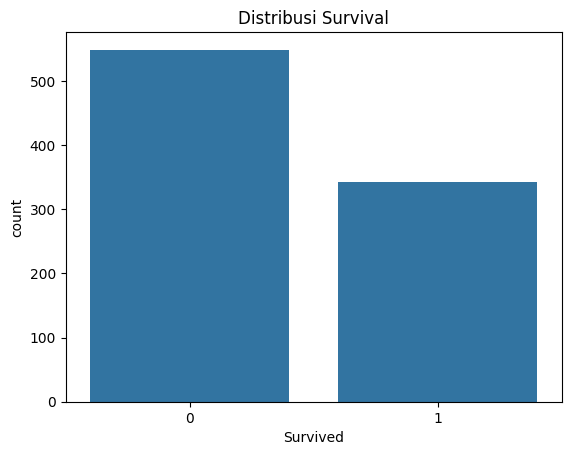

In [9]:
sns.countplot(x='Survived', data=df)
plt.title("Distribusi Survival")
plt.show()

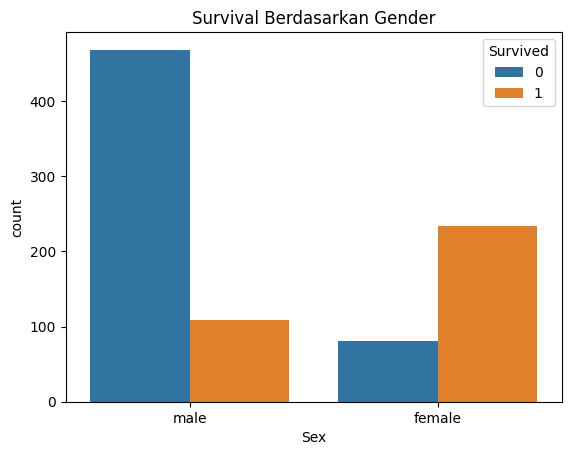

In [10]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival Berdasarkan Gender")
plt.show()

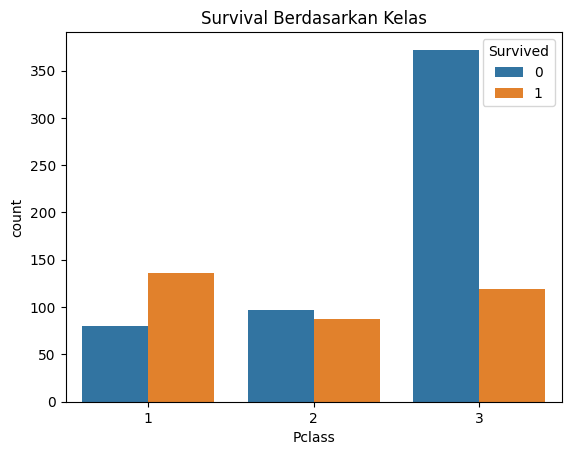

In [11]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival Berdasarkan Kelas")
plt.show()

In [12]:
df = df.drop(
    columns=[
        'PassengerId',
        'Name',
        'Ticket',
        'Cabin'
    ]
)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


# **5. Data Preprocessing**
Tahap preprocessing dilakukan untuk membersihkan data dan mempersiapkannya sebelum digunakan dalam proses pelatihan model. Proses yang dilakukan meliputi penanganan missing value, penghapusan fitur yang tidak relevan, serta encoding data kategorikal menjadi numerik.


In [13]:
df['Age'] = df['Age'].fillna(
    df['Age'].median()
)

In [14]:
df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

In [15]:
df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,S
1,1,1,1,38.0,1,0,71.2833,C
2,1,3,1,26.0,0,0,7.9250,S
3,1,1,1,35.0,1,0,53.1000,S
4,0,3,0,35.0,0,0,8.0500,S


In [16]:
df = pd.get_dummies(
    df,
    columns=['Embarked'],
    drop_first=True
)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(2), float64(2), int64(5)
memory usage: 50.6 KB


In [18]:
df.to_csv(
    "titanic_preprocessing.csv",
    index=False
)

print("Dataset berhasil disimpan")

Dataset berhasil disimpan


In [19]:
processed_df = pd.read_csv(
    "titanic_preprocessing.csv"
)

processed_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [20]:
from google.colab import files

files.download(
    "titanic_preprocessing.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>